In [20]:
import os, json, math, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, f1_score
)

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [21]:
# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Paths & constants
DATA_CSV      = "data_final.csv"         # or "processing/data_final.csv"
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 64

OUT_DIR       = Path("outputs_logreg")
CACHE_DIR     = OUT_DIR / "cache"
ARTIFACTS_DIR = OUT_DIR / "artifacts"
for d in [OUT_DIR, CACHE_DIR, ARTIFACTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EMB_NPY_PATH  = CACHE_DIR / "embeddings_resnet50.npy"
EMB_MAP_JSON  = CACHE_DIR / "emb_index.json"
SCALER_PATH   = ARTIFACTS_DIR / "scaler.pkl"
MODEL_PATH    = ARTIFACTS_DIR / "logreg.pkl"
CFG_JSON      = ARTIFACTS_DIR / "feature_config.json"
THRESH_JSON   = ARTIFACTS_DIR / "decision_threshold.json"

# Reduce TF log noise
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

# Optional GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU memory growth warning:", e)


## Load data & normalize labels

In [22]:

df = pd.read_csv(DATA_CSV)

required_cols = {"path_a","path_b","duplicate"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns {missing}. Need {required_cols}")

# Normalize label to 0/1 if object
if df["duplicate"].dtype == object:
    le = LabelEncoder()
    df["duplicate"] = le.fit_transform(df["duplicate"])
    print("LabelEncoder for 'duplicate', classes:", list(le.classes_))

# Drop NA rows (paths/label)
before = len(df)
df = df.dropna(subset=["path_a","path_b","duplicate"])
print(f"Dropped {before - len(df)} NA rows (if any)")

# Filter nonexistent files
def file_exists(p): 
    try: return Path(p).is_file()
    except: return False

mask_exist = df["path_a"].apply(file_exists) & df["path_b"].apply(file_exists)
if not mask_exist.all():
    print(f"{(~mask_exist).sum()} rows with missing files -> removed")
    df = df[mask_exist].reset_index(drop=True)

print("Label distribution:\n", df["duplicate"].value_counts())
df.head()


Dropped 0 NA rows (if any)
Label distribution:
 duplicate
True     260
False    260
Name: count, dtype: int64


,path_a,title_a,path_b,title_b,duplicate
0,images_png/camera/194121937.png,Camera IP Wifi Ngoài Trời EZVIZ C3TN 3MP 2K Co...,images_png/camera/194130039.png,Camera IP Wifi Ngoài Trời EZVIZ H3 5MP Độ Phân...,True
1,images_png/phone/273990229.png,Điện Thoại Xiaomi Redmi Note 13 6GB/128GB - Hà...,images_png/phone/276944892.png,Điện Thoại Samsung Galaxy A06 4GB/64GB - Hàng ...,True
2,images_png/camera/275938579.png,"Camera trong nhà TP-Link Tapo TC60 - Full HD, ...",images_png/phone/277777809.png,"Điện thoại Samsung Galaxy A26 5G (8/128GB), Mặ...",False
3,images_png/phone/276274790.png,Điện Thoại Samsung Galaxy A06 4GB/128GB - Hàng...,images_png/phone/276944892.png,Điện Thoại Samsung Galaxy A06 4GB/64GB - Hàng ...,True
4,images_png/phone/276639232.png,Điện Thoại Samsung Galaxy A16 5G 8GB/128GB - H...,images_png/phone/276944868.png,Điện Thoại Samsung Galaxy A16 4GB/128GB - Hàng...,True


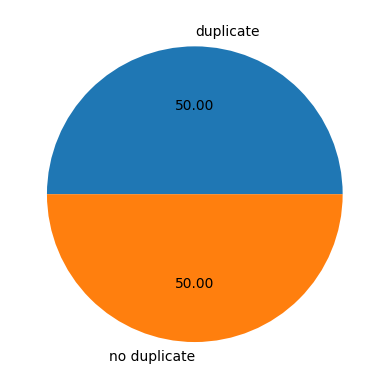

In [23]:
plt.pie(df['duplicate'].value_counts(), labels=['duplicate','no duplicate'],autopct="%0.2f")
plt.show()

## Train/Test Split (stratified)

In [24]:

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["duplicate"]
)
y_train = train_df["duplicate"].to_numpy()
y_test  = test_df["duplicate"].to_numpy()
print(f"Train: {len(train_df)} | Test: {len(test_df)}")


Train: 416 | Test: 104


## Build/Load ResNet50 embeddings (cached)

In [25]:

# ResNet50 backbone (frozen)
base = ResNet50(weights="imagenet", include_top=False, pooling="avg")
base.trainable = False

def tf_load(path_str):
    img = tf.io.read_file(path_str)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img

def embed_batch(paths):
    ds = tf.data.Dataset.from_tensor_slices([str(p) for p in paths])
    ds = ds.map(tf_load, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)
    outs = []
    for batch in ds:
        emb = base(batch, training=False).numpy()
        outs.append(emb)
    return np.vstack(outs) if outs else np.zeros((0, 2048), dtype=np.float32)

def ensure_embeddings(all_paths):
    # Load cache if available
    if EMB_NPY_PATH.exists() and EMB_MAP_JSON.exists():
        emb = np.load(EMB_NPY_PATH)
        with open(EMB_MAP_JSON, "r") as f:
            idx_map = json.load(f)
    else:
        emb = np.zeros((0, 2048), dtype=np.float32)
        idx_map = {}

    # Find missing
    to_add = [p for p in all_paths if p not in idx_map]
    if to_add:
        print(f"Embedding {len(to_add)} new images (cache has {len(idx_map)}) ...")
        new_emb = embed_batch(to_add)
        start = len(emb)
        emb = np.vstack([emb, new_emb]) if len(emb) else new_emb
        for i, p in enumerate(to_add):
            idx_map[p] = start + i
        # Save cache
        np.save(EMB_NPY_PATH, emb)
        with open(EMB_MAP_JSON, "w") as f:
            json.dump(idx_map, f)
        print("Updated cache:", EMB_NPY_PATH, EMB_MAP_JSON)
    else:
        print(f"Using cached embeddings ({len(idx_map)} images)")

    return emb, idx_map

# Unique paths across train & test
unique_paths = pd.unique(pd.concat([train_df["path_a"], train_df["path_b"],
                                    test_df["path_a"],  test_df["path_b"]])).astype(str)
emb_all, emb_index = ensure_embeddings(unique_paths)

def get_emb_of(paths):
    idxs = [emb_index[p] for p in paths]
    return emb_all[idxs]


Using cached embeddings (311 images)


## Construct pairwise features

In [26]:

# Features: |a-b| (2048), a*b (2048), cosine (1), L2 (1) => 4098 dims
def pair_features(emb_a, emb_b):
    abs_diff = np.abs(emb_a - emb_b)
    prod     = emb_a * emb_b
    dot = np.sum(emb_a * emb_b, axis=1)
    na  = np.linalg.norm(emb_a, axis=1) + 1e-12
    nb  = np.linalg.norm(emb_b, axis=1) + 1e-12
    cos = (dot / (na * nb)).reshape(-1, 1)
    l2  = np.linalg.norm(emb_a - emb_b, axis=1).reshape(-1, 1)
    return np.hstack([abs_diff, prod, cos, l2])

# Train
emb_a_tr = get_emb_of(train_df["path_a"].astype(str).tolist())
emb_b_tr = get_emb_of(train_df["path_b"].astype(str).tolist())
X_train  = pair_features(emb_a_tr, emb_b_tr)

# Test
emb_a_te = get_emb_of(test_df["path_a"].astype(str).tolist())
emb_b_te = get_emb_of(test_df["path_b"].astype(str).tolist())
X_test   = pair_features(emb_a_te, emb_b_te)

X_train.shape, X_test.shape


((416, 4098), (104, 4098))

## Scale features & train Logistic Regression

In [27]:

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1,
    solver="lbfgs",
)
clf.fit(X_train_sc, y_train)

# Save artifacts
joblib.dump(scaler, SCALER_PATH)
joblib.dump(clf,    MODEL_PATH)
with open(CFG_JSON, "w") as f:
    json.dump({
        "img_size": IMG_SIZE,
        "features": ["abs_diff(2048)", "prod(2048)", "cos(1)", "l2(1)"],
        "embedding": "ResNet50(ImageNet, avg pool, frozen)"
    }, f, indent=2)
print(f"Saved scaler → {SCALER_PATH}")
print(f"Saved model  → {MODEL_PATH}")


Saved scaler → outputs_logreg/artifacts/scaler.pkl
Saved model  → outputs_logreg/artifacts/logreg.pkl


## Evaluation @ threshold = 0.5


Classification Report (thr=0.5)
              precision    recall  f1-score   support

       False     1.0000    0.9808    0.9903        52
        True     0.9811    1.0000    0.9905        52

    accuracy                         0.9904       104
   macro avg     0.9906    0.9904    0.9904       104
weighted avg     0.9906    0.9904    0.9904       104

ROC AUC: 0.9985
Confusion Matrix @0.5:
 [[51  1]
 [ 0 52]]


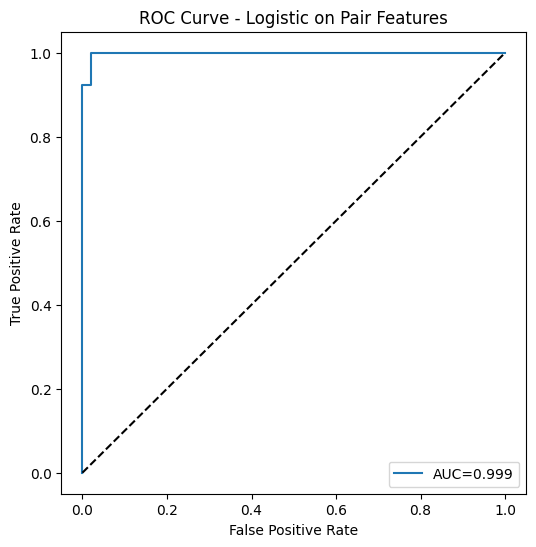

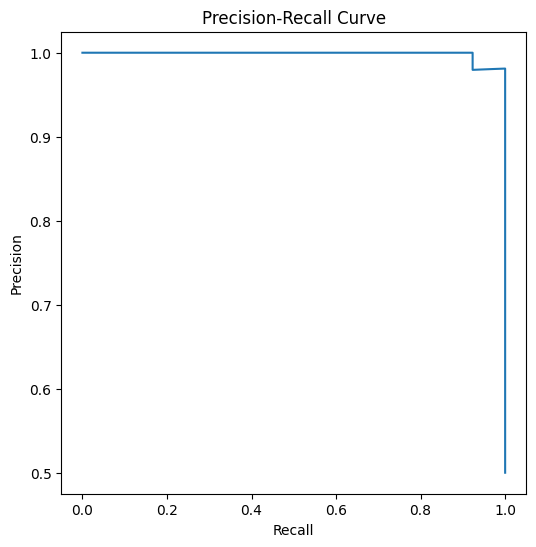

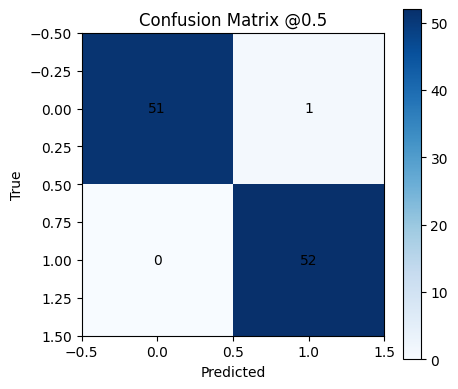

In [28]:

proba = clf.predict_proba(X_test_sc)[:, 1]
pred05 = (proba >= 0.5).astype(int)

print("\nClassification Report (thr=0.5)")
print(classification_report(y_test, pred05, digits=4))

auc = roc_auc_score(y_test, proba)
fpr, tpr, _ = roc_curve(y_test, proba)
prec, rec, _ = precision_recall_curve(y_test, proba)
cm = confusion_matrix(y_test, pred05)

print(f"ROC AUC: {auc:.4f}")
print("Confusion Matrix @0.5:\n", cm)

# ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic on Pair Features"); plt.legend()
plt.show()

# PR
plt.figure(figsize=(6,6))
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Confusion Matrix
fig = plt.figure(figsize=(4.8,4.2))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix @0.5"); plt.colorbar()
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()

## Optimize decision threshold by F1

In [29]:

best_t, best_f1 = 0.5, f1_score(y_test, pred05)
for t in np.linspace(0.05, 0.95, 19):
    f1 = f1_score(y_test, (proba >= t).astype(int))
    if f1 > best_f1:
        best_f1, best_t = f1, t

with open(THRESH_JSON, "w") as f:
    json.dump({"threshold": float(best_t), "f1_on_test": float(best_f1)}, f, indent=2)

print(f"Best F1={best_f1:.4f} at threshold={best_t:.2f}")
print(f"Saved decision threshold → {THRESH_JSON}")


Best F1=0.9905 at threshold=0.50
Saved decision threshold → outputs_logreg/artifacts/decision_threshold.json


## Inference on a random test pair + side-by-side preview


Random Pair Prediction (Logistic)
Image A: images_png/laptop/278226626.png
Image B: images_png/laptop/278227010.png
Ground Truth: 1 | Predicted: 1 (p=1.000, thr=0.50)


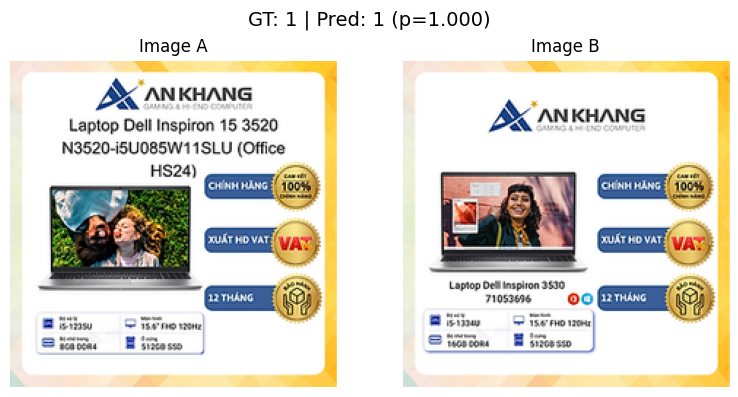

In [32]:
import matplotlib.pyplot as plt
from PIL import Image

def make_features_for_pair(path_a, path_b):
    ea = get_emb_of([path_a])
    eb = get_emb_of([path_b])
    return pair_features(ea, eb)

def predict_pair(path_a, path_b, model_path=MODEL_PATH, scaler_path=SCALER_PATH, thr_path=THRESH_JSON):
    scaler_ = joblib.load(scaler_path)
    clf_    = joblib.load(model_path)
    with open(thr_path, "r") as f:
        thr = json.load(f)["threshold"]

    X = make_features_for_pair(path_a, path_b)
    Xs = scaler_.transform(X)
    p  = float(clf_.predict_proba(Xs)[0,1])
    y  = int(p >= thr)
    return y, p, thr

# Chọn ngẫu nhiên 1 cặp từ test set
row = test_df.sample(1, random_state=random.randint(0, 10**9)).iloc[0]
pa, pb, gt = str(row["path_a"]), str(row["path_b"]), int(row["duplicate"])

pred, p, thr = predict_pair(pa, pb)
print("\nRandom Pair Prediction (Logistic)")
print(f"Image A: {pa}")
print(f"Image B: {pb}")
print(f"Ground Truth: {gt} | Predicted: {pred} (p={p:.3f}, thr={thr:.2f})")

# Hiển thị ảnh trực tiếp
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open(pa).convert("RGB"))
axes[0].axis("off")
axes[0].set_title("Image A")
axes[1].imshow(Image.open(pb).convert("RGB"))
axes[1].axis("off")
axes[1].set_title("Image B")
plt.suptitle(f"GT: {gt} | Pred: {pred} (p={p:.3f})", fontsize=14)
plt.tight_layout()
plt.show()